In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.core.defchararray import join, mod
import albumentations as A
import torch
import cv2
from PIL import Image
from io import BytesIO
import random
from tqdm.notebook import tqdm
import torch.nn as nn
from torch._C import device
import torch.optim as optim
import torch.autograd.grad_mode as grad_mode
from torch.autograd import Function as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms as torchtrans
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.rpn import AnchorGenerator
import os

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    devie = torch.device("cpu")

In [3]:
device

device(type='cuda')

In [4]:
def img_show(number, title=None, size=5):
    root = "/kaggle/input/guns-object-detection/"
    image = cv2.imread(root + "Images/" + str(number) + ".jpeg")

    file = open(root + "Labels/" + str(number) + ".txt")
    file_data = file.readlines()
    file.close()

    for i in range(0, int(file_data[0])):
        indices = [int(x) for x in file_data[i+1].split()]
        start_pt = (indices[0], indices[1])
        end_pt = (indices[2], indices[3])
        cv2.rectangle(image, start_pt, end_pt, (0,0,255), 2)

    aspect_ratio = image.shape[0]/image.shape[1]
    plt.figure(figsize=(size+aspect_ratio, size))

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title+file_data[0])
    plt.show()

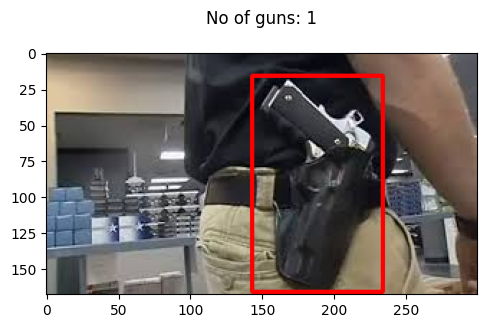

In [5]:
img_show(105, title="No of guns: ")

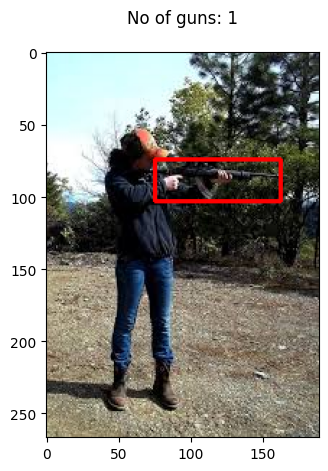

In [6]:
img_show(151, title="No of guns: ")

In [7]:
class GunData(Dataset):
    def __init__(self, root):
        self.image_path = root+"Images/"
        self.labels_path = root+"Labels/"
        self.images = [i for i in sorted(os.listdir(self.image_path))]
        self.labels = [l for l in sorted(os.listdir(self.labels_path))]

    def __getitem__(self,idx):
        img = cv2.imread(os.path.join(self.image_path, str(self.images[idx])))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img_res = img_rgb/255
        img_res = torch.as_tensor(img_res).permute(2,0,1)

        label_name = self.images[idx][:-4]+"txt"
        label = os.path.join(str(self.labels_path) ,str(label_name))

        with open(label, 'r') as l:
            c = int(l.readline())
            box=[]
            for i in range(c):
                box.append(list(map(int, l.readline().split())))     

        target={}
        area=[]
        labels=[]

        for i in range(len(box)):
            a = (box[i][2] - box[i][0]) * (box[i][3] - box[i][1])
            area.append(a)

        for i in range(len(box)):
            labels.append(1)

        target["boxes"] = torch.as_tensor(box)
        target["area"] = torch.as_tensor(area)
        target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        target["image_id"] = torch.as_tensor([idx])

        img_res = img_res.to(device)
        for key in target:
            if isinstance(target[key], torch.Tensor):
                target[key] = target[key].to(device)

        return img_res, target

    def __len__(self):
        return len(self.images)
        

In [8]:
class Model:
    def __init__(self, num):
        self.num = num
        self.model= self.create_model()

    def create_model(self):
        model = fasterrcnn_resnet50_fpn(pretrained=True)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, self.num)
        return model

    def compiler(self, optimizer):
        self.optimizer = optimizer

    def train(self, train_data, val_data):
        for epoch in tqdm(range(num_epoch)):
            self.model = self.model.to(device)

            train_loss = 0
            self.model.train()

            for img, target in train_data:
                loss_dic = self.model(img, target)
                loss = sum(loss for loss in loss_dic.values())
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                train_loss += loss
            print(f"Epoch: {epoch+1} | train_loss: {train_loss}")
        

In [9]:
rcnn = Model(2)
model = rcnn.model
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epoch = 30
rcnn.compiler(optimizer)

def collate(batch):
    return tuple(zip(*batch))

dataset = GunData("/kaggle/input/guns-object-detection/")

train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=3, shuffle=True,num_workers=0, collate_fn = collate)
val_loader = DataLoader(val_data, batch_size=3, shuffle=False,num_workers=0, collate_fn = collate)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 200MB/s] 


In [10]:
rcnn.train(train_loader, val_loader)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 22.631210327148438
Epoch: 2 | train_loss: 17.029918670654297
Epoch: 3 | train_loss: 14.476844787597656
Epoch: 4 | train_loss: 12.517107009887695
Epoch: 5 | train_loss: 11.253401756286621
Epoch: 6 | train_loss: 9.149137496948242
Epoch: 7 | train_loss: 8.207876205444336
Epoch: 8 | train_loss: 8.178604125976562
Epoch: 9 | train_loss: 7.65615701675415
Epoch: 10 | train_loss: 6.923032283782959
Epoch: 11 | train_loss: 6.278353214263916
Epoch: 12 | train_loss: 6.196817398071289
Epoch: 13 | train_loss: 5.688461780548096
Epoch: 14 | train_loss: 5.026439189910889
Epoch: 15 | train_loss: 4.702807903289795
Epoch: 16 | train_loss: 5.092166900634766
Epoch: 17 | train_loss: 4.566503524780273
Epoch: 18 | train_loss: 4.3484416007995605
Epoch: 19 | train_loss: 4.226659297943115
Epoch: 20 | train_loss: 4.063409328460693
Epoch: 21 | train_loss: 4.151798248291016
Epoch: 22 | train_loss: 4.161712169647217
Epoch: 23 | train_loss: 3.74251389503479
Epoch: 24 | train_loss: 3.7191274166107

In [11]:
def test(data, n=random.randint(1,334)):
    img, target = data[n]
    model.eval()

    predictions = model([img])
    predictions = [{k:v.to(device) for k,v in t.items()} for t in predictions]
                  
    return predictions, target, img

In [12]:
def apply_nms(og_pred, iou_thresh=None):
    keep = torchvision.ops.nms(og_pred["boxes"], og_pred["scores"], iou_thresh)
    final_predictions = og_pred
    final_predictions["boxes"] = final_predictions["boxes"][keep]
    final_predictions["scores"] = final_predictions["scores"][keep]
    final_predictions["labels"] = final_predictions["labels"][keep]
    return final_predictions

In [13]:
def torch_to_pil(img):
    return torchtrans.ToPILImage()(img).convert("RGB")

In [14]:
def plot_bb(img, target, size=5):
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    for box in target["boxes"]:
        x,y,w,h = box.tolist()
        cv2.rectangle(img_cv, (int(x), int(y)), (int(x+w),int(y+h)) , (0,0,255), 2)
    aspect_ratio = img_cv.shape[0]/img_cv.shape[1]
    plt.figure(figsize=(size+aspect_ratio, size))
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.show()
    

In [15]:
predictions, target, img = test(dataset, n=12)

In [16]:
nms = apply_nms(predictions[0], iou_thresh=0.7)

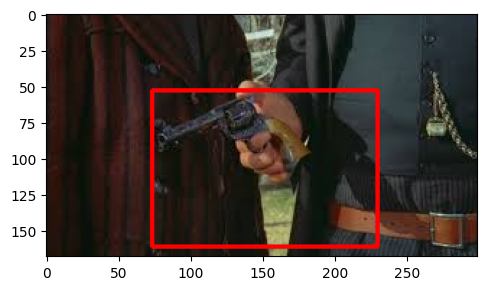

In [17]:
plot_bb(torch_to_pil(img), target)

In [18]:
torch.save(model.state_dict(), "F_RCNN.pth")